In [9]:
!pip install matplotlib --user

     |████████████████████████████████| 8.3 MB 10.9 MB/s            
     |████████████████████████████████| 19.5 MB 9.0 MB/s             
     |████████████████████████████████| 321 kB 10.9 MB/s            
     |████████████████████████████████| 1.6 MB 8.7 MB/s            
     |████████████████████████████████| 6.6 MB 3.5 MB/s            
     |████████████████████████████████| 4.8 MB 16.7 MB/s            
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import subprocess
import time
import glob

# submit the job
result = subprocess.run(
    ['sbatch', '/home/admin/slurm-gpu-setup/gpu-burn.sh'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

# get job id
job_id = result.stdout.strip().split()[-1]
print(f"Job ID: {job_id}")

Submitted batch job 65


Job ID: 65


In [6]:
# check status
result = subprocess.run(['squeue', '-j', job_id], capture_output=True, text=True)
print(result.stdout)

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)
                65     debug gpu-burn    admin  R       4:04      2 slurm[01-02]



In [7]:
# read output
time.sleep(5)
outfile = f"/home/admin/slurm-logs/slurm-{job_id}.out"
with open(outfile) as f:
    print(f.read())

=== GPU Burn started at Mon  8 Jun 10:07:43 IST 2026 ===
=== Job ID: 65 ===
=== Node: slurm01 ===
=== Node: slurm01 ===
GPU 0: NVIDIA GeForce GTX 1080 (UUID: GPU-3335927d-5537-c0f9-0224-abe028a30907)
GPU 0: NVIDIA GeForce GTX 1080 (UUID: GPU-3ec794a8-5530-251b-4bb1-d5ab16ffb638)
Using compare file: compare.ptx
Burning for 300 seconds.
Using compare file: compare.ptx
Burning for 300 seconds.

1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 26 (6159 Gflop/s)   errors: 0   temps: 24 C 
1.7%  proc'd: 2

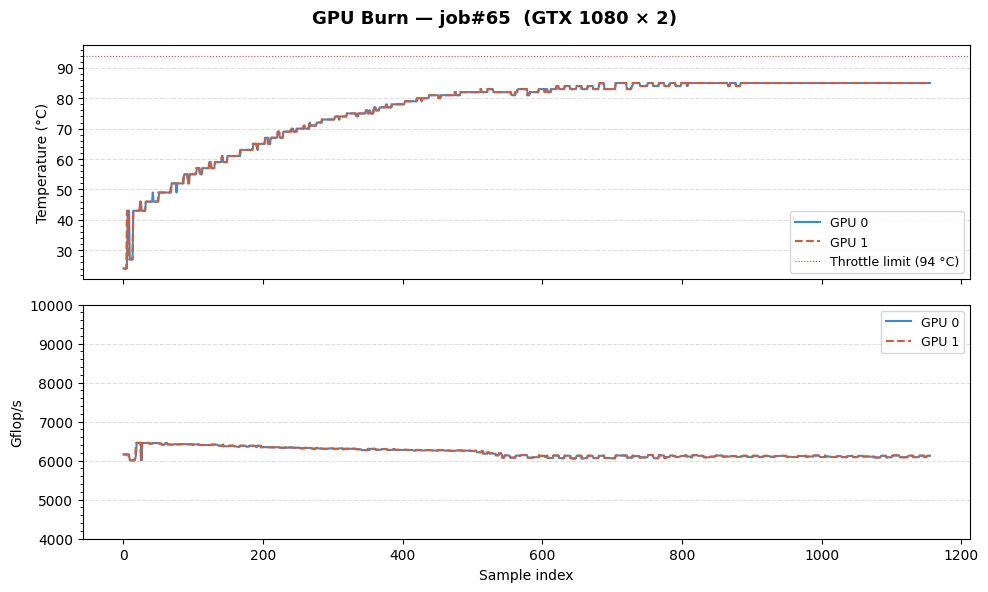

In [15]:
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

LOG_FILE = outfile

gpu0_temps, gpu0_gflops = [], []
gpu1_temps, gpu1_gflops = [], []

pattern = re.compile(
    r"^\s*(\d+\.\d+)%\s+proc'd:\s*\d+\s+\((\d+)\s+Gflop/s\)\s+errors:\s*0\s+temps:\s*(\d+)"
)

with open(LOG_FILE) as f:
    lines = f.readlines()

MAX_GFLOPS = 15000

toggle = True
for line in lines:
    m = pattern.match(line.lstrip())
    if m:
        gflops = int(m.group(2))
        temp   = int(m.group(3))
        
        if gflops > MAX_GFLOPS or temp > 100 or temp < 20:
            continue
            
        if toggle:
            gpu0_gflops.append(gflops)
            gpu0_temps.append(temp)
        else:
            gpu1_gflops.append(gflops)
            gpu1_temps.append(temp)
        toggle = not toggle

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle(f"GPU Burn — job#{job_id}  (GTX 1080 × 2)", fontsize=13, fontweight="bold")

ax1.plot(gpu0_temps, label="GPU 0", color="#378ADD", linewidth=1.5)
ax1.plot(gpu1_temps, label="GPU 1", color="#D85A30", linewidth=1.5, linestyle="--")
ax1.set_ylabel("Temperature (°C)")
ax1.axhline(94, color="#E24B4A", linewidth=0.8, linestyle=":", label="Throttle limit (94 °C)")
ax1.legend(fontsize=9)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.grid(axis="y", linestyle="--", alpha=0.4)

ax2.plot(gpu0_gflops, label="GPU 0", color="#378ADD", linewidth=1.5)
ax2.plot(gpu1_gflops, label="GPU 1", color="#D85A30", linewidth=1.5, linestyle="--")
ax2.set_ylabel("Gflop/s")
ax2.set_xlabel("Sample index")
ax2.set_ylim(4000, 10000)
ax2.legend(fontsize=9)
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("gpu_burn_results.png", dpi=150, bbox_inches="tight")
plt.show()